In [1]:
import scqubits
import numpy as np
from scipy.optimize import minimize

In [2]:
EJ = 3
EC = 0.6
EL = 0.13

qubit_level = 30

def get_shift(ele,Delta_ij):
    return abs(ele)**2 / Delta_ij

qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=qubit_level)
evals = qbt.eigenvals(qubit_level)
elements = qbt.matrixelement_table('n_operator',evals_count = qubit_level)

def shift_diff(x):
    points_nearby = []
    for Er in [x-1e-5, x, x+1e-5]:
        shifts_from_one = [get_shift(elements[1,ql2],evals[ql2]-evals[1]-Er) for ql2 in range(qubit_level)] 
        shift_from_one = sum(shifts_from_one)
        shifts_from_two = [get_shift(elements[2,ql2],evals[ql2]-evals[2]-Er) for ql2 in range(qubit_level)] 
        shift_from_two = sum(shifts_from_two)
        points_nearby.append(abs(shift_from_one-shift_from_two))
    return sum(points_nearby)

initial_guess = [7.35]

# Call the optimizer
result = minimize(shift_diff, initial_guess, method='Nelder-Mead')

print("Result:", result)
print("Optimal solution:", result.x)
print("Objective value:", result.fun)


Result:        message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.9900055399091343e-06
             x: [ 7.262e+00]
           nit: 14
          nfev: 30
 final_simplex: (array([[ 7.262e+00],
                       [ 7.262e+00]]), array([ 1.990e-06,  2.190e-05]))
Optimal solution: [7.2622522]
Objective value: 1.9900055399091343e-06


In [1]:
from utils import *


qubit 12 transition and differential stark at different oscillator level
qbt freq at osc 0:	0.009120899850767472
qbt freq at osc 1:	0.00909, 	diff to at osc ground -0.00003, 0.3788% diff
qbt freq at osc 2:	0.00906, 	diff to at osc ground -0.00006, 0.6723% diff
qbt freq at osc 3:	0.00904, 	diff to at osc ground -0.00008, 0.8601% diff
qbt freq at osc 4:	0.00904, 	diff to at osc ground -0.00009, 0.9356% diff
qbt freq at osc 5:	0.00904, 	diff to at osc ground -0.00008, 0.8940% diff
qbt freq at osc 6:	0.00905, 	diff to at osc ground -0.00007, 0.7321% diff
qbt freq at osc 7:	0.00908, 	diff to at osc ground -0.00004, 0.4484% diff
qbt freq at osc 8:	0.00912, 	diff to at osc ground -0.00000, 0.0420% diff
qbt freq at osc 9:	0.00917, 	diff to at osc ground 0.00004, 0.4869% diff
qbt freq at osc 10:	0.00922, 	diff to at osc ground 0.00010, 1.1374% diff
qbt freq at osc 11:	0.00929, 	diff to at osc ground 0.00017, 1.9080% diff
qbt freq at osc 12:	0.00938, 	diff to at osc ground 0.00026, 2.7967% diff

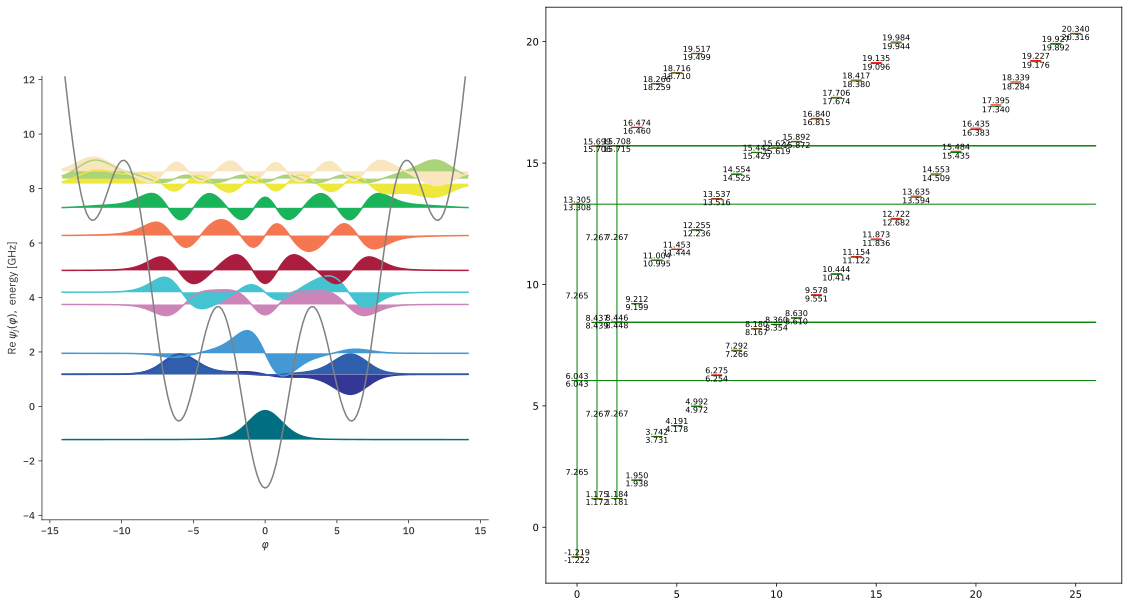

In [3]:
system = fluxonium_oscillator_system(
    EJ = 3,
    EC = 0.6,
    EL = 0.13,
    Er = 7.2622522,
    g_strength = 0.3,
    qubit_level = 30,
    osc_level = 30,
    kappa = 0.004,
    products_to_keep=[[ql, ol] for ql in range(30) for ol in range(30) ]
    )


energies=  system.hilbertspace.eigenvals(900)
def dressed_ener(ql,ol):
    return energies[system.product_to_dressed[(ql,ol)]]
def print_stats():
    print(f"\nqubit 12 transition and differential stark at different oscillator level")
    print(f"qbt freq at osc {0}:\t{(dressed_ener(2,0)-dressed_ener(1,0))}")
    ground_freq = dressed_ener(2,0)-dressed_ener(1,0)
    for i in range(1,29):
        freq = dressed_ener(2,i)-dressed_ener(1,i)
        print(f"qbt freq at osc {i}:\t{freq:.5f}, \tdiff to at osc ground {freq - ground_freq:.5f}, {abs(freq - ground_freq)/ground_freq*100:.4f}% diff")

    print(f"\noscillator freq at qubit level:\t0 \t 1 \t 2 \t 3:")
    print(f"oscillator transition 0-1: \t{dressed_ener(0,1)-dressed_ener(0,0):.5f}\t{dressed_ener(1,1)-dressed_ener(1,0):.5f}\t{dressed_ener(2,1)-dressed_ener(2,0):.5f}\t{dressed_ener(3,1)-dressed_ener(3,0):.5f}")
    for i in range(1,10):
        print(f"oscillator transition {i}-{i+1}: \t{dressed_ener(0,i+1)-dressed_ener(0,i):.5f}\t{dressed_ener(1,i+1)-dressed_ener(1,i):.5f}\t{dressed_ener(2,i+1)-dressed_ener(2,i):.5f}\t{dressed_ener(3,i+1)-dressed_ener(3,i):.5f}  oscillator frequency coupled to qubit 0th state compared to 00-01 (non-linearity): {(dressed_ener(0,i+1)-dressed_ener(0,i))  -(dressed_ener(0,1)-dressed_ener(0,0))}")

    print(f"")
    print(f"10-11: {(dressed_ener(1,1)-dressed_ener(1,0)):.4f}, diff to 00-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(1,1)-dressed_ener(1,0)))}")
    print(f"20-21: {(dressed_ener(2,1)-dressed_ener(2,0)):.4f}, diff to 00-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(2,1)-dressed_ener(2,0)))}")
print_stats()
plot_specturum(system.qbt, system.osc, system.hilbertspace,num_levels = 50)

(<Figure size 1000x500 with 3 Axes>, (<Axes3D: >, <Axes: >))

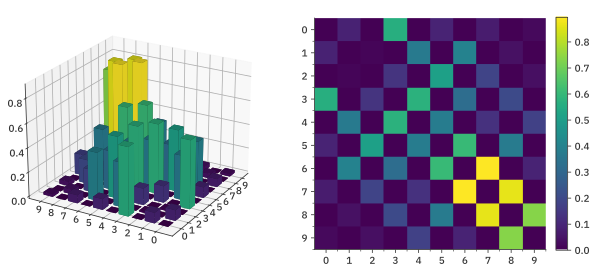

In [6]:
system.qbt.plot_matrixelements('n_operator',evals_count = 10)